<a href="https://colab.research.google.com/github/adal2122/Clase14Nov2023/blob/ramaPrueba2/Calculo%20de%20estudiantes%20y%20promedios%20generales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Integrador: Analisis de calificaciones de estudiantes


--- PROYECTO INTEGRADOR: Análisis Escolar ---



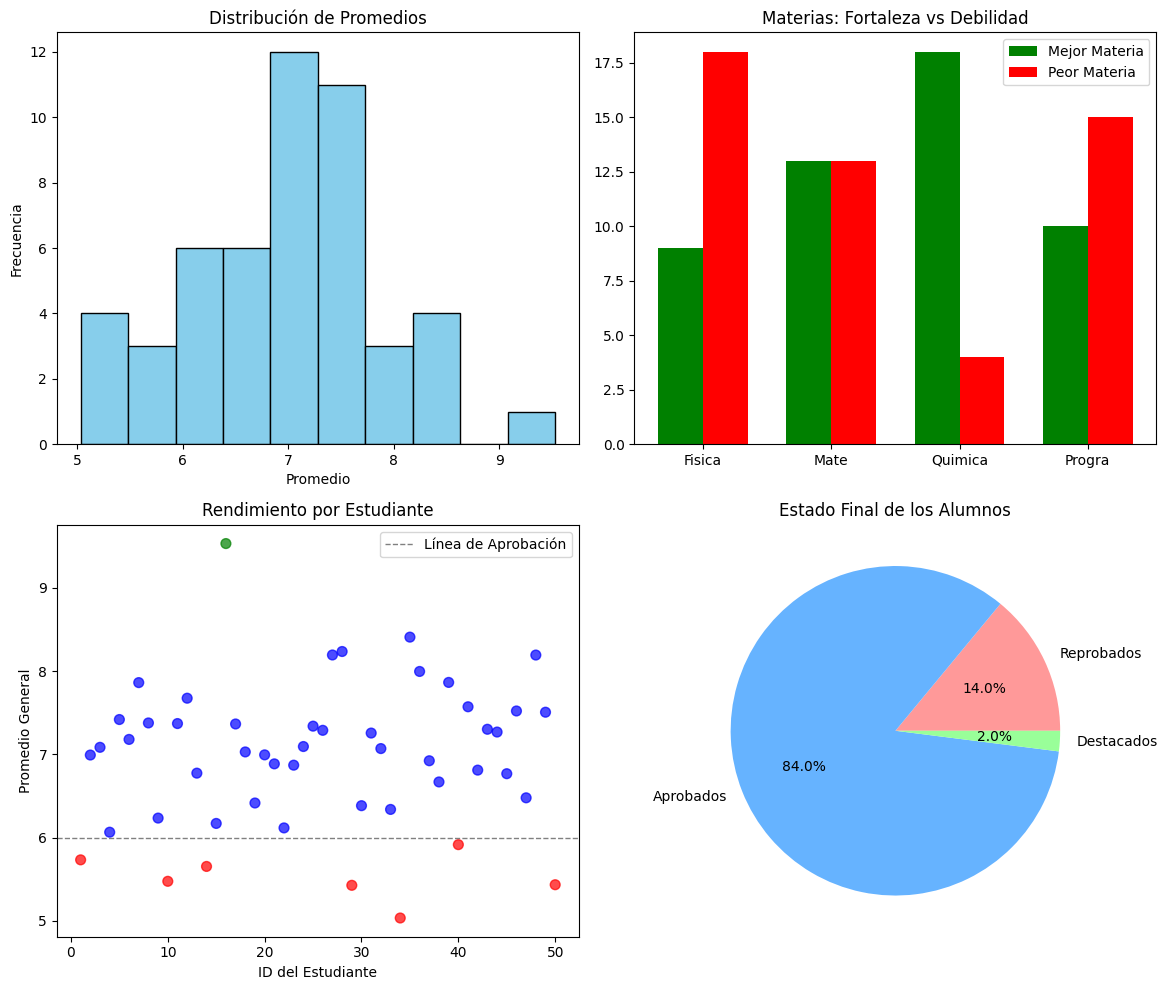


 RESUMEN FINAL 
Total Alumnos: 50
Reprobados: 7
Aprobados:  42
Destacados: 1
------------------------------
Promedio General del Grupo: 6.97


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("\n--- PROYECTO INTEGRADOR: Análisis Escolar ---\n")

# -----------------------------------------------------------------
# 1. GENERAR DATOS
# -----------------------------------------------------------------
np.random.seed(50)
n_alumnos = 50

ids = np.arange(1, n_alumnos + 1)

# Generamos las notas
fisica = np.random.normal(6.5, 6, n_alumnos)
mate = np.random.normal(7.0, 2.2, n_alumnos)
quimica = np.random.normal(8.0, 10, n_alumnos)
progra = np.random.normal(7.5, 2.5, n_alumnos)

# Ajustes de rango (0 a 10)
fisica = np.clip(fisica, 0, 10)
mate = np.clip(mate, 0, 10)
quimica = np.clip(quimica, 0, 10)
progra = np.clip(progra, 0, 10)


# -----------------------------------------------------------------
# 2. CLASE ESTUDIANTE
# -----------------------------------------------------------------
class Estudiante:
    def __init__(self, numero, fis, ma, qui, pro):
        self.numero = numero
        self.fis = fis
        self.ma = ma
        self.qui = qui
        self.pro = pro

        self.promedio = (fis + ma + qui + pro) / 4
        self.estado = self.obtener_estado()
        self.mejor_materia = self.obtener_mejor()
        self.peor_materia = self.obtener_peor()

    def obtener_estado(self):
        if self.promedio < 6.0:
            return "Reprobado"
        elif self.promedio >= 8.5:
            return "Destacado"
        else:
            return "Aprobado"

    def obtener_mejor(self):
        notas = [self.fis, self.ma, self.qui, self.pro]
        nombres = ['Fisica', 'Mate', 'Quimica', 'Progra']
        nota_maxima = max(notas)
        indice = notas.index(nota_maxima)
        return nombres[indice]

    def obtener_peor(self):
        notas = [self.fis, self.ma, self.qui, self.pro]
        nombres = ['Fisica', 'Mate', 'Quimica', 'Progra']
        nota_minima = min(notas)
        indice = notas.index(nota_minima)
        return nombres[indice]


# -----------------------------------------------------------------
# 3. PROCESAR ALUMNOS
# -----------------------------------------------------------------
lista_estudiantes = []
for i in range(n_alumnos):
    alumno = Estudiante(ids[i], fisica[i], mate[i], quimica[i], progra[i])
    lista_estudiantes.append(alumno)

# Listas de datos
lista_promedios = [e.promedio for e in lista_estudiantes]
lista_estados = [e.estado for e in lista_estudiantes]
lista_mejores = [e.mejor_materia for e in lista_estudiantes]
lista_peores = [e.peor_materia for e in lista_estudiantes]

# Conteos
cant_reprobados = lista_estados.count("Reprobado")
cant_aprobados = lista_estados.count("Aprobado")
cant_destacados = lista_estados.count("Destacado")

# -----------------------------------------------------------------
# 4. GRÁFICAS
# -----------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- GRÁFICA 1 : Histograma ---
axes[0, 0].hist(lista_promedios, bins=10, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribución de Promedios')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_xlabel('Promedio')

# --- GRÁFICA 2 : Materias Fortaleza vs Debilidad ---
materias = ['Fisica', 'Mate', 'Quimica', 'Progra']
conteo_faciles = [lista_mejores.count(m) for m in materias]
conteo_dificiles = [lista_peores.count(m) for m in materias]

x = np.arange(len(materias))
ancho = 0.35

axes[0, 1].bar(x - ancho / 2, conteo_faciles, ancho, label='Mejor Materia', color='green')
axes[0, 1].bar(x + ancho / 2, conteo_dificiles, ancho, label='Peor Materia', color='red')

axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(materias)
axes[0, 1].set_title('Materias: Fortaleza vs Debilidad')
axes[0, 1].legend()

# --- GRÁFICA 3 : DISPERSIÓN DE ALUMNOS ---
# Asignamos colores a cada punto (alumno) según su estado
colores_puntos = []
for estado in lista_estados:
    if estado == "Reprobado":
        colores_puntos.append('red')
    elif estado == "Destacado":
        colores_puntos.append('green')
    else:
        colores_puntos.append('blue')

axes[1, 0].scatter(ids, lista_promedios, c=colores_puntos, s=50, alpha=0.7)
axes[1, 0].set_title('Rendimiento por Estudiante')
axes[1, 0].set_xlabel('ID del Estudiante')
axes[1, 0].set_ylabel('Promedio General')
# Agregamos una línea roja punteada en el 6.0 para ver el límite
axes[1, 0].axhline(y=6.0, color='gray', linestyle='--', linewidth=1, label='Línea de Aprobación')
axes[1, 0].legend()

# --- GRÁFICA 4 : Pastel de Aprobados ---
datos_pastel = [cant_reprobados, cant_aprobados, cant_destacados]
etiquetas = ['Reprobados', 'Aprobados', 'Destacados']
colores_pastel = ['#ff9999', '#66b3ff', '#99ff99']

axes[1, 1].pie(datos_pastel, labels=etiquetas, autopct='%1.1f%%', colors=colores_pastel)
axes[1, 1].set_title('Estado Final de los Alumnos')

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------
# 5. RESUMEN FINAL
# -----------------------------------------------------------------
print("\n" + "=" * 30)
print(" RESUMEN FINAL ")
print("=" * 30)
print(f"Total Alumnos: {n_alumnos}")
print(f"Reprobados: {cant_reprobados}")
print(f"Aprobados:  {cant_aprobados}")
print(f"Destacados: {cant_destacados}")
print("-" * 30)
print(f"Promedio General del Grupo: {np.mean(lista_promedios):.2f}")